# Predictions per model

In [4]:
import sys
sys.path.append('../src')

import re
import ast
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from Config.config import PATHS
from Utils.utils import GetMeasurements
from Utils.interaction import Performer
from Utils.indices import AlternationIndex
from Classes.cognitive_model_agents import (
    PayoffM2, AttendanceM2, FocalRegionAgent, FRAplus
)

In [5]:
free_parameters = {
    'inverse_temperature': 8,
    'learning_rate': 0.2,
    'bias': 1,
    'forget': 0.8,
    'len_history': 2,
    'delta': 0.4,
    'max_regions': 5,
}

In [6]:
simulation_parameters = {
    'num_rounds': 100,
    'num_episodes': 50,
    'verbose': False
}
df_list = []

# list_fix_parameters = [(3, 0.7)]
# list_fix_parameters = [(2, 0.5), (3, 0.4), (3, 0.8)]
# list_fix_parameters = [(4, 0.3), (4, 0.5), (4, 0.8)]
list_fix_parameters = [
    (2, 0.5), 
    (3, 0.4), (3, 0.7), 
    (4, 0.3), (4, 0.5), (4, 0.8),
]

for num_agents, threshold in list_fix_parameters:
    fixed_parameters = {
        'num_agents': num_agents,
        'threshold': threshold,
    }
    for model_class in [PayoffM2, AttendanceM2, FocalRegionAgent]:
        df2 = Performer.sim(
            agent_class=model_class,
            fixed_parameters=fixed_parameters,
            free_parameters=free_parameters,
            simulation_parameters=simulation_parameters,
        )
        df2['model'] = model_class.name()
        df_list.append(df2)
df2 = pd.concat(df_list, ignore_index=True)
df2['bounded_score'] = df2['score'] / df2['threshold']

  0%|          | 0/50 [00:00<?, ?it/s]

  0%|          | 0/50 [00:00<?, ?it/s]

  0%|          | 0/50 [00:00<?, ?it/s]

  0%|          | 0/50 [00:00<?, ?it/s]

  0%|          | 0/50 [00:00<?, ?it/s]

...

  0%|          | 0/50 [00:00<?, ?it/s]

  0%|          | 0/50 [00:00<?, ?it/s]

  0%|          | 0/50 [00:00<?, ?it/s]

  0%|          | 0/50 [00:00<?, ?it/s]

  0%|          | 0/50 [00:00<?, ?it/s]

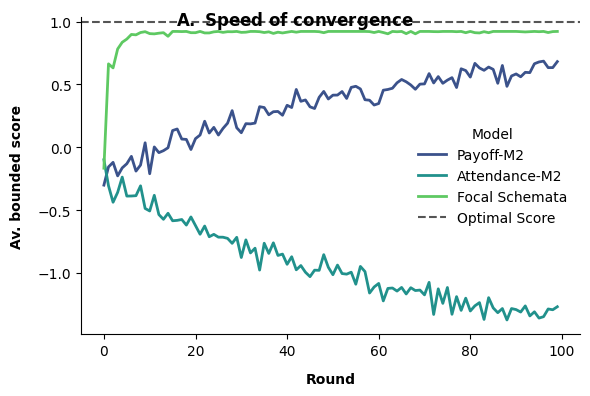

In [7]:
# 2. Initialize the plot with standard journal dimensions
fig, ax = plt.subplots(figsize=(6, 4))

# 3. Create the line plot with a professional palette
# 'rocket_r' or 'viridis' look much more academic than default bright colors
sns.lineplot(
    x='round', 
    y='bounded_score', 
    hue='model',
    palette='viridis', 
    linewidth=2,
    errorbar=None, 
    data=df2,
    ax=ax
)

# 4. Draw the horizontal baseline (muted color, labeled)
optimal_score = 1
# optimal_score = int(fixed_parameters['threshold'] * fixed_parameters['num_agents']) / fixed_parameters['num_agents']
ax.axhline(
    y=optimal_score, 
    color='#555555',       # Muted dark grey instead of harsh red
    linestyle='--', 
    linewidth=1.5,
    label='Optimal Score'  # Added label for the legend
)

# 5. Clean up labels and presentation
ax.set_xlabel('Round', fontweight='bold', labelpad=10)
ax.set_ylabel('Av. bounded score', fontweight='bold', labelpad=10)
#ax.set_ylim([-0.25, 1.1])

# De-clutter the legend and place it cleanly
ax.legend(title=r'Model', frameon=True, facecolor='white', edgecolor='none')

# 6. Final professional touches
sns.despine()            # Removes the top and right spines
plt.tight_layout()       # Ensures nothing gets cut off

fig.suptitle(r"$\bf{A.}$ Speed of convergence", fontweight='bold')

plt.show()

In [8]:
fig.savefig(PATHS['exploratory_figures'] / 'Models_speed.png', dpi=300)

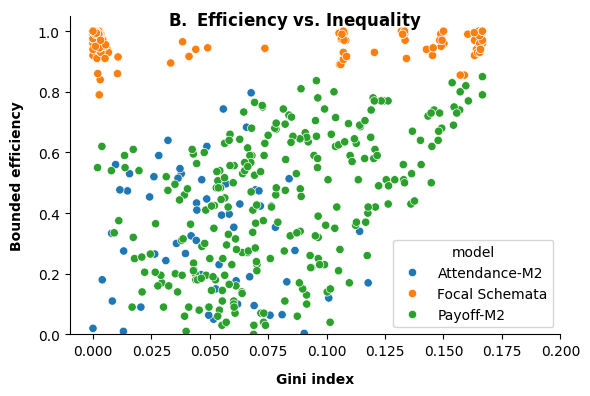

In [9]:
gm = GetMeasurements(
    data=df2, measures=['bounded_efficiency', 'conditional_entropy', 'gini_index']
)
data = gm.get_measurements()

fig, ax = plt.subplots(figsize=(6, 4))

ax = sns.scatterplot(
    x='gini_index', y='bounded_efficiency',
    hue='model',
    data=data,
    ax=ax
)
ax.set_xlabel('Gini index', fontweight='bold', labelpad=10)
ax.set_ylabel('Bounded efficiency', fontweight='bold', labelpad=10)
ax.set_xlim([-0.01, 0.2])
ax.set_ylim([-0.00, 1.05])

sns.despine()            # Removes the top and right spines
plt.tight_layout()       # Ensures nothing gets cut off

fig.suptitle(r"$\bf{B.}$ Efficiency vs. Inequality", fontweight='bold')

plt.show()

In [10]:
fig.savefig(PATHS['exploratory_figures'] / 'Models_vs.png', dpi=300)

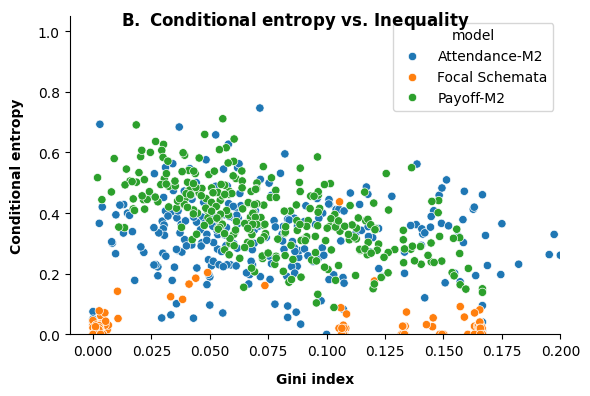

In [11]:
fig, ax = plt.subplots(figsize=(6, 4))

ax = sns.scatterplot(
    x='gini_index', y='conditional_entropy',
    hue='model',
    data=data,
    ax=ax
)
ax.set_xlabel('Gini index', fontweight='bold', labelpad=10)
ax.set_ylabel('Conditional entropy', fontweight='bold', labelpad=10)
ax.set_xlim([-0.01, 0.2])
ax.set_ylim([-0.00, 1.05])

sns.despine()            # Removes the top and right spines
plt.tight_layout()       # Ensures nothing gets cut off

fig.suptitle(r"$\bf{B.}$ Conditional entropy vs. Inequality", fontweight='bold')

plt.show()

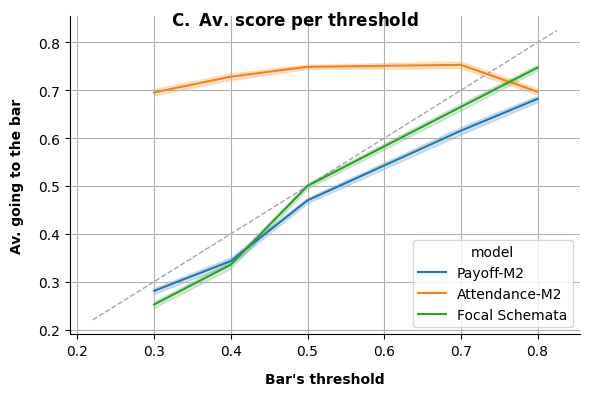

In [12]:
fig, ax = plt.subplots(figsize=(6, 4))

sns.lineplot(
    x='threshold', y='decision',
    hue='model',
    data=df2, 
    ax=ax,
)
ax.grid()
x0, x1 = ax.get_xlim()
y0, y1 = ax.get_ylim()
lo, hi = min(x0, y0), max(x1, y1)
ax.plot([lo, hi], [lo, hi], color='gray', linestyle='--', linewidth=1, alpha=0.7, zorder=0)
ax.set_xlabel("Bar's threshold", fontweight='bold', labelpad=10)
ax.set_ylabel("Av. going to the bar", fontweight='bold', labelpad=10)

sns.despine()            # Removes the top and right spines
plt.tight_layout()       # Ensures nothing gets cut off

fig.suptitle(r"$\bf{C.}$ Av. score per threshold", fontweight='bold')

plt.show()

In [13]:
fig.savefig(PATHS['exploratory_figures'] / 'Models_threshold.png', dpi=300)

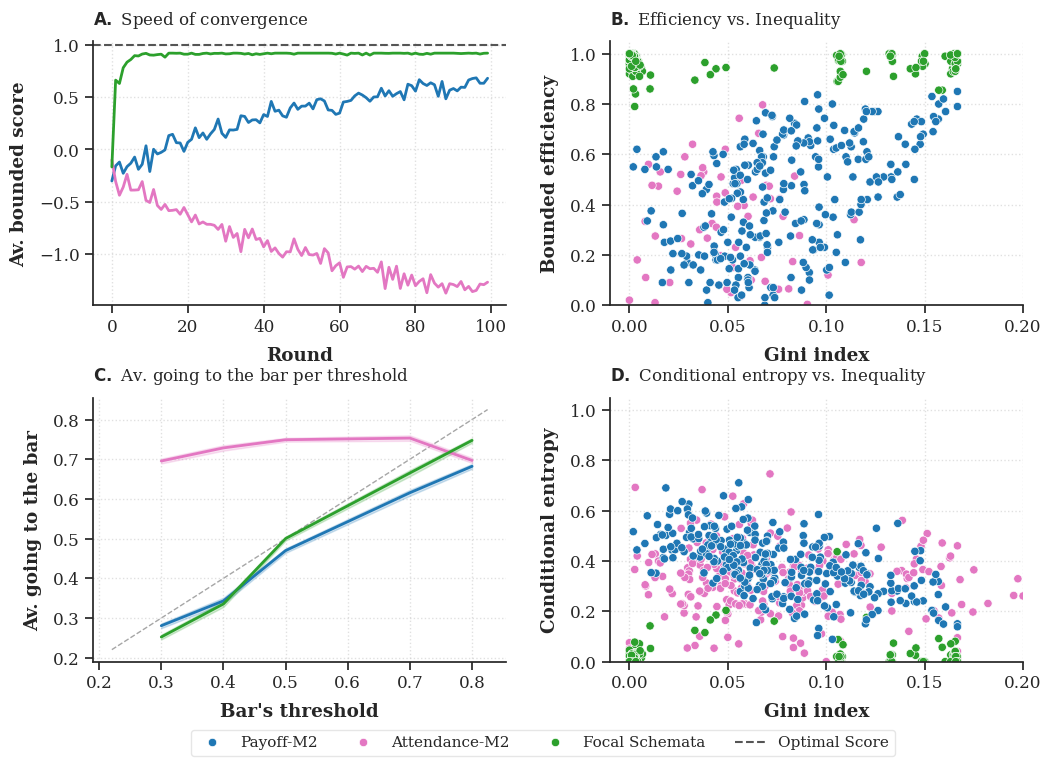

In [14]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

# 1. Global Academic Styling
sns.set_theme(style="ticks", font_scale=1.1)
plt.rcParams["font.family"] = "serif"

# 2. Strict Model Coloring and Labeling for Consistency
model_order = ['Payoff-M2', 'Attendance-M2', 'Focal Schemata']
model_palette = {
    'Payoff-M2': '#1f77b4',
    'Attendance-M2': '#e377c2',
    'Focal Schemata': '#2ca02c'
}

# Set up a 12x8.5 figure (slightly taller to gracefully accommodate the bottom legend)
fig = plt.figure(figsize=(12, 8.5))

# Leave an explicit 15% margin at the bottom (bottom=0.15) for the unified legend
gs = gridspec.GridSpec(2, 2, figure=fig, hspace=0.35, wspace=0.25, bottom=0.15)

# Assign subplot axes
ax_A = fig.add_subplot(gs[0, 0])  # Top Left
ax_B = fig.add_subplot(gs[0, 1])  # Top Right
ax_C = fig.add_subplot(gs[1, 0])  # Bottom Left
ax_D = fig.add_subplot(gs[1, 1])  # Bottom Right

axes = [ax_A, ax_B, ax_C, ax_D]

# =====================================================================
# SUBPLOT A: Speed of convergence
# =====================================================================
sns.lineplot(
    x='round', y='bounded_score', hue='model', 
    hue_order=model_order, palette=model_palette, 
    linewidth=2, errorbar=None, data=df2, ax=ax_A,
    legend=False  # Suppress individual legend
)
# optimal_score = int(fixed_parameters['threshold'] * fixed_parameters['num_agents']) / fixed_parameters['num_agents']
optimal_score = 1
ax_A.axhline(
    y=optimal_score, color='#555555', linestyle='--', 
    linewidth=1.5, label='Optimal Score'  # Gathered later for the unified legend
)
ax_A.set_xlabel('Round', fontweight='bold', labelpad=8)
ax_A.set_ylabel('Av. bounded score', fontweight='bold', labelpad=8)
ax_A.set_title(r"$\bf{A.}$ Speed of convergence", loc='left', pad=12, fontsize=12)

# =====================================================================
# SUBPLOT B: Efficiency vs. Inequality
# =====================================================================
sns.scatterplot(
    x='gini_index', y='bounded_efficiency', hue='model', 
    hue_order=model_order, palette=model_palette, 
    data=data, ax=ax_B,
    legend=False  # Suppress individual legend
)
ax_B.set_xlabel('Gini index', fontweight='bold', labelpad=8)
ax_B.set_ylabel('Bounded efficiency', fontweight='bold', labelpad=8)
ax_B.set_xlim([-0.01, 0.2])
ax_B.set_ylim([-0.00, 1.05])
ax_B.set_title(r"$\bf{B.}$ Efficiency vs. Inequality", loc='left', pad=12, fontsize=12)

# =====================================================================
# SUBPLOT C: Av. going to the bar per threshold
# =====================================================================
sns.lineplot(
    x='threshold', y='decision', hue='model',
    hue_order=model_order, palette=model_palette,
    data=df2, ax=ax_C, color='#2c3e50', linewidth=2,
    legend=False,
)
x0, x1 = ax_C.get_xlim()
y0, y1 = ax_C.get_ylim()
lo, hi = min(x0, y0), max(x1, y1)
ax_C.plot([lo, hi], [lo, hi], color='gray', linestyle='--', linewidth=1, alpha=0.7, zorder=0)

ax_C.set_xlabel("Bar's threshold", fontweight='bold', labelpad=8)
ax_C.set_ylabel("Av. going to the bar", fontweight='bold', labelpad=8)
ax_C.set_title(r"$\bf{C.}$ Av. going to the bar per threshold", loc='left', pad=12, fontsize=12)

# =====================================================================
# SUBPLOT D: Conditional entropy vs. Inequality
# =====================================================================
# We let this plot generate a clean legend template to extract our labels from
sns.scatterplot(
    x='gini_index', y='conditional_entropy', hue='model',
    hue_order=model_order, palette=model_palette,
    data=data, ax=ax_D,
    legend='brief'  
)
ax_D.set_xlabel('Gini index', fontweight='bold', labelpad=8)
ax_D.set_ylabel('Conditional entropy', fontweight='bold', labelpad=8)
ax_D.set_xlim([-0.01, 0.2])
ax_D.set_ylim([-0.00, 1.05])
ax_D.set_title(r"$\bf{D.}$ Conditional entropy vs. Inequality", loc='left', pad=12, fontsize=12)

# Extract handles and labels from D before turning off its legend
model_handles, model_labels = ax_D.get_legend_handles_labels()
ax_D.get_legend().remove()  # Remove it from the plot area cleanly

# =====================================================================
# Building the Unified Legend
# =====================================================================
# Combine the 3 Model handles from Panel D + the 1 Baseline handle from Panel A
opt_handle, opt_label = ax_A.get_legend_handles_labels()
all_handles = model_handles + opt_handle
all_labels = model_labels + opt_label

# Draw the legend globally at the bottom center of the figure canvas
fig.legend(
    handles=all_handles,
    labels=all_labels,
    loc='lower center',
    bbox_to_anchor=(0.5, 0.03), # Center horizontally (0.5), push down to bottom (0.03)
    ncol=4,                     # Align them cleanly side-by-side in one row
    frameon=True,
    facecolor='white',
    edgecolor='#e0e0e0',
    fontsize=11
)

# =====================================================================
# Uniform Styling Clean-up
# =====================================================================
for ax in axes:
    ax.grid(True, linestyle=':', alpha=0.6, color='#cccccc')
    ax.set_axisbelow(True) 
    sns.despine(ax=ax)

plt.show()

In [16]:
fig.savefig(PATHS['exploratory_figures'] / 'models.png', dpi=300)